# RAG Workflow 테스트 (CRAG — Corrective RAG)

```
START → rewrite → internal_search
internal_search → [internal_relevance_edge]
    ├─ relevant    → answer → END
    ├─ rewrite     → rewrite (retry)
    └─ web_search  → web_search → [web_relevance_edge]
                        ├─ relevant   → answer → END
                        └─ irrelevant → fallback → END
```

## 0. 환경 설정

In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv, find_dotenv

dotenv_path = find_dotenv()
loaded = load_dotenv(dotenv_path, override=True)
print(f".env: {dotenv_path} | loaded: {loaded}")

project_root = str(Path(dotenv_path).parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"project root: {project_root}")

.env: /Users/kimjunghyeon/Desktop/workspace/ai-agent/.env | loaded: True
project root: /Users/kimjunghyeon/Desktop/workspace/ai-agent


## 1. 워크플로우 그래프 시각화

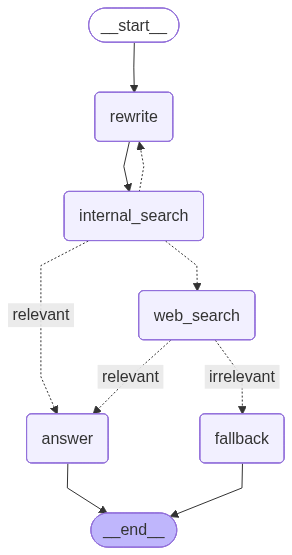

노드 목록: ['__start__', 'rewrite', 'internal_search', 'web_search', 'answer', 'fallback']


In [6]:
from IPython.display import Image

from app.agents.workflows.rag_workflow import create_rag_workflow

app = create_rag_workflow()
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

print("노드 목록:", list(app.nodes.keys()))

## 2. 내부 검색 경로 테스트 (internal_search → answer)

업로드된 문서에 관한 질문 → `rewrite → internal_search → relevant → answer` 경로 검증

In [9]:
import uuid
from langchain_core.messages import HumanMessage

from app.agents.state import RAGState

print("=== 내부 검색 경로 테스트 ===\n")

query = "B2B 마켓플레이스 출시가 언제된거야?"

initial_state: RAGState = {
    "messages": [HumanMessage(content=query)],
    "original_query": query,
    "rewritten_query": "",
    "keywords": [],
    "rag_context": "",
    "citations": [],
    "search_source": "internal",
    "retry_count": 0,
    "user_id": "test-user",
    "answer": None,
}

node_sequence = []
current_node = None

async for mode, chunk in app.astream(initial_state, stream_mode=["values", "updates"]):
    if mode == "updates":
        current_node = list(chunk.keys())[0]
        node_sequence.append(current_node)

    elif mode == "values":
        print(f"{'─' * 60}")
        print(f"  node           : {current_node}")
        print(f"  rewritten_query: {chunk.get('rewritten_query', '')[:80]}")
        print(f"  keywords       : {chunk.get('keywords', [])}")
        print(f"  search_source  : {chunk.get('search_source', '')}")
        print(f"  retry_count    : {chunk.get('retry_count', 0)}")
        rag_ctx = chunk.get('rag_context', '')
        print(f"  rag_context    : {rag_ctx[:100]}{'...' if len(rag_ctx) > 100 else ''}")
        answer = chunk.get('answer') or ''
        print(f"  answer         : {answer}")

print(f"\n{'─' * 60}")
print(f"실행 노드 순서: {node_sequence}")
assert "rewrite" in node_sequence, "rewrite 노드가 실행되지 않음"
assert "internal_search" in node_sequence, "internal_search 노드가 실행되지 않음"
print("✅ 내부 검색 경로 테스트 완료")

=== 내부 검색 경로 테스트 ===

────────────────────────────────────────────────────────────
  node           : None
  rewritten_query: 
  keywords       : []
  search_source  : internal
  retry_count    : 0
  rag_context    : 
  answer         : 
────────────────────────────────────────────────────────────
  node           : rewrite
  rewritten_query: B2B 마켓플레이스의 출시 날짜는 언제인가요?
  keywords       : ['B2B', '마켓플레이스', '출시', '날짜']
  search_source  : internal
  retry_count    : 1
  rag_context    : 
  answer         : 
────────────────────────────────────────────────────────────
  node           : internal_search
  rewritten_query: B2B 마켓플레이스의 출시 날짜는 언제인가요?
  keywords       : ['B2B', '마켓플레이스', '출시', '날짜']
  search_source  : internal
  retry_count    : 1
  rag_context    : [1] 출처: fy25회사소개서그룹사국문버전.pdf
\* | 이테크시스템 대전지사, 부산지사 개소\<br>에티버스이비티, B2B 전문 온라인 쇼핑몰 ‘...
  answer         : 
────────────────────────────────────────────────────────────
  node           : answer
  rewritten_query: B2B

## 3. 웹 검색 경로 테스트 (internal_search → web_search)

내부 문서에 없는 최신 정보 질문 → `rewrite → internal_search → web_search → answer` 경로 검증

In [11]:
print("=== 웹 검색 경로 테스트 ===\n")

query = "2025년 최신 LLM 모델 트렌드를 알려줘"

initial_state: RAGState = {
    "messages": [HumanMessage(content=query)],
    "original_query": query,
    "rewritten_query": "",
    "keywords": [],
    "rag_context": "",
    "citations": [],
    "search_source": "internal",
    "retry_count": 0,
    "user_id": "test-user",
    "answer": None,
}

node_sequence = []
current_node = None

async for mode, chunk in app.astream(initial_state, stream_mode=["values", "updates"]):
    if mode == "updates":
        current_node = list(chunk.keys())[0]
        node_sequence.append(current_node)

    elif mode == "values":
        print(f"{'─' * 60}")
        print(f"  node           : {current_node}")
        print(f"  rewritten_query: {chunk.get('rewritten_query', '')[:80]}")
        print(f"  search_source  : {chunk.get('search_source', '')}")
        citations = chunk.get('citations', [])
        print(f"  citations      : {citations[:3]}")
        answer = chunk.get('answer') or ''
        print(f"  answer         : {answer}")

print(f"\n{'─' * 60}")
print(f"실행 노드 순서: {node_sequence}")
print("✅ 웹 검색 경로 테스트 완료")

=== 웹 검색 경로 테스트 ===

────────────────────────────────────────────────────────────
  node           : None
  rewritten_query: 
  search_source  : internal
  citations      : []
  answer         : 
────────────────────────────────────────────────────────────
  node           : rewrite
  rewritten_query: 2025년의 최신 대형 언어 모델 트렌드에 대해 설명해 주세요.
  search_source  : internal
  citations      : []
  answer         : 
────────────────────────────────────────────────────────────
  node           : internal_search
  rewritten_query: 2025년의 최신 대형 언어 모델 트렌드에 대해 설명해 주세요.
  search_source  : internal
  citations      : ['fy25회사소개서그룹사국문버전.pdf']
  answer         : 
────────────────────────────────────────────────────────────
  node           : rewrite
  rewritten_query: 2025년 대형 언어 모델의 최신 트렌드에 대한 설명
  search_source  : internal
  citations      : ['fy25회사소개서그룹사국문버전.pdf']
  answer         : 
────────────────────────────────────────────────────────────
  node           : interna

## 4. astream_events — LLM 토큰 스트리밍 확인

`on_chat_model_stream` 이벤트로 answer 노드의 토큰이 실시간으로 흘러오는지 검증

In [ ]:
print("=== astream_events LLM 토큰 스트리밍 테스트 ===\n")

query = "RAG 시스템이란 무엇인가요?"

initial_state: RAGState = {
    "messages": [HumanMessage(content=query)],
    "original_query": query,
    "rewritten_query": "",
    "keywords": [],
    "rag_context": "",
    "citations": [],
    "search_source": "internal",
    "retry_count": 0,
    "user_id": "test-user",
    "answer": None,
}

collected_tokens = []
node_events = []

async for event in app.astream_events(initial_state, version="v2"):
    event_type = event["event"]
    event_name = event.get("name", "")

    # 노드 시작
    if event_type == "on_chain_start" and event_name in ("rewrite", "internal_search", "web_search", "answer", "fallback"):
        node_events.append(("START", event_name))
        print(f"[NODE START] {event_name}")

    # 노드 종료
    elif event_type == "on_chain_end" and event_name in ("rewrite", "internal_search", "web_search", "answer", "fallback"):
        node_events.append(("END", event_name))
        output = event.get("data", {}).get("output", {})
        if event_name == "rewrite":
            print(f"  rewritten_query : {output.get('rewritten_query', '')[:80]}")
            print(f"  keywords        : {output.get('keywords', [])}")
        elif event_name == "internal_search":
            ctx = output.get('rag_context', '')
            print(f"  rag_context     : {ctx[:100]}{'...' if len(ctx) > 100 else '(없음)' if not ctx else ''}")
        elif event_name == "answer":
            print(f"  answer          : {output.get('answer', '')[:120]}")
        print(f"[NODE END  ] {event_name}")

    # LLM 토큰 스트리밍 (answer 노드)
    elif event_type == "on_chat_model_stream" and event_name == "answer":
        chunk = event["data"].get("chunk")
        if chunk and hasattr(chunk, "content") and chunk.content:
            collected_tokens.append(chunk.content)
            print(chunk.content, end="", flush=True)

print(f"\n\n{'─' * 60}")
print(f"수집된 토큰 수 : {len(collected_tokens)}")
print(f"노드 이벤트    : {node_events}")
print("✅ astream_events 스트리밍 테스트 완료")

## 5. rewrite 재시도 경로 테스트

내부 검색 결과가 관련 없을 때 `retry_count < MAX_RETRIES` 이면 rewrite로 돌아가는지 검증

In [ ]:
from app.core.config import settings

print("=== rewrite 재시도 경로 테스트 ===\n")
print(f"RAG_MAX_RETRIES = {settings.RAG_MAX_RETRIES}")

# 내부에 없을 가능성이 높은 쿼리
query = "아주 구체적인 존재하지 않는 문서의 7번째 챕터 3절 내용을 알려줘"

initial_state: RAGState = {
    "messages": [HumanMessage(content=query)],
    "original_query": query,
    "rewritten_query": "",
    "keywords": [],
    "rag_context": "",
    "citations": [],
    "search_source": "internal",
    "retry_count": 0,
    "user_id": "test-user",
    "answer": None,
}

node_sequence = []
max_retry_count = 0

async for mode, chunk in app.astream(initial_state, stream_mode=["values", "updates"]):
    if mode == "updates":
        current_node = list(chunk.keys())[0]
        node_sequence.append(current_node)

    elif mode == "values":
        retry = chunk.get('retry_count', 0)
        if retry > max_retry_count:
            max_retry_count = retry
        answer = chunk.get('answer') or ''
        if answer:
            print(f"  최종 answer: {answer[:200]}")

print(f"\n실행 노드 순서 : {node_sequence}")
print(f"최대 retry_count: {max_retry_count}")
rewrite_count = node_sequence.count("rewrite")
print(f"rewrite 실행 횟수: {rewrite_count}")
print("✅ rewrite 재시도 경로 테스트 완료")

## 6. process_rag_agent 단순 호출 테스트

`process_rag_agent()` 진입점 함수로 최종 결과(answer, citations, search_source)를 확인

In [ ]:
from app.agents.workflows.rag_workflow import process_rag_agent

print("=== process_rag_agent 호출 테스트 ===\n")

query = "LangGraph의 StateGraph란 무엇인가요?"

result = await process_rag_agent(
    messages=[HumanMessage(content=query)],
    original_query=query,
    user_id="test-user",
)

print(f"search_source : {result.get('search_source')}")
print(f"citations     : {result.get('citations')}")
print(f"\nanswer:\n{result.get('answer')}")

assert result.get("answer"), "answer가 비어있음"
print("\n✅ process_rag_agent 테스트 통과")

## 7. 복수 질의 테스트

다양한 질문 유형별로 `search_source`, `citations`, `answer` 결과를 한눈에 비교

In [ ]:
print("=== 복수 질의 비교 테스트 ===\n")

test_queries = [
    "업로드된 문서에서 핵심 개념을 찾아줘",
    "FastAPI와 LangGraph를 함께 사용하는 방법은?",
    "오늘 날씨가 어때?",
]

for i, query in enumerate(test_queries, 1):
    print(f"[{i}] 질문: {query}")
    result = await process_rag_agent(
        messages=[HumanMessage(content=query)],
        original_query=query,
        user_id="test-user",
    )
    answer = result.get('answer', '')
    print(f"     search_source : {result.get('search_source')}")
    print(f"     citations     : {result.get('citations', [])}")
    print(f"     answer        : {answer[:150]}{'...' if len(answer) > 150 else ''}")
    print()

print("✅ 복수 질의 테스트 완료")

## 8. 테스트 요약

In [ ]:
print("=" * 65)
print("RAG WORKFLOW (CRAG) 테스트 요약")
print("=" * 65)

test_summary = [
    "그래프 시각화 (create_rag_workflow)",
    "내부 검색 경로 (rewrite → internal_search → answer)",
    "웹 검색 경로 (internal_search → web_search → answer)",
    "astream_events LLM 토큰 스트리밍",
    "rewrite 재시도 경로 (retry_count 증가 검증)",
    "process_rag_agent 진입점 호출",
    "복수 질의 search_source 비교",
]

for name in test_summary:
    print(f"  ✅ {name}")

print()
print("검증 항목:")
print("  - rewrite 노드가 항상 첫 번째로 실행됨")
print("  - internal_relevance_edge가 3-way 분기(relevant/rewrite/web_search) 수행")
print("  - web_relevance_edge가 2-way 분기(relevant/irrelevant) 수행")
print("  - retry_count가 MAX_RETRIES 초과 시 web_search로 escalate")
print("  - answer 노드에서 LLM 토큰이 실시간 스트리밍")
print("  - citations에 출처(파일명 or URL)가 포함")
print("=" * 65)